# House Price Prediction using Linear Regression

## Objective

The objective of this project is to predict house prices based on various housing features such as area, bedrooms, bathrooms, stories, parking, and other amenities.

This project demonstrates:

- Data Loading
- Data Cleaning
- Exploratory Data Analysis (EDA)
- Feature Engineering
- Linear Regression Modeling
- Model Evaluation

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [8]:
hp=pd.read_csv(r"C:\Users\Leo\Downloads\archive (7).zip")

In [9]:
hp.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## Dataset Overview

The dataset was loaded successfully and inspected using:

- shape()
- info()
- describe()

### Key Observations

- Identified the total number of rows and columns.
- Checked data types of all features.
- Verified the target variable (price).
- Examined statistical properties of numerical columns.

In [10]:
hp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [12]:
hp.shape

(20640, 10)

In [13]:
hp.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Missing Value Analysis

Missing values can negatively impact model performance.

The dataset was checked for null values across all columns to ensure data quality before training.

In [15]:
hp.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [17]:
hp["total_bedrooms"] = hp["total_bedrooms"].fillna(
    hp["total_bedrooms"].mean()
)

## Duplicate Record Analysis

Duplicate records can introduce bias into machine learning models.

The dataset was checked for duplicate entries and duplicates were removed if found.

In [19]:
hp.duplicated().sum()

np.int64(0)

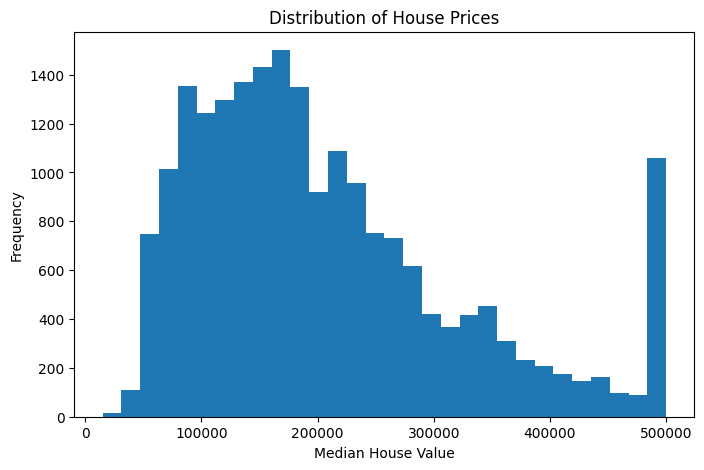

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(hp["median_house_value"], bins=30)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.show()

## Distribution of House Prices

The target variable was visualized to understand the distribution of house prices.

This helps identify:

- Data skewness
- Outliers
- Overall price distribution

Understanding the target variable is crucial before building predictive models.

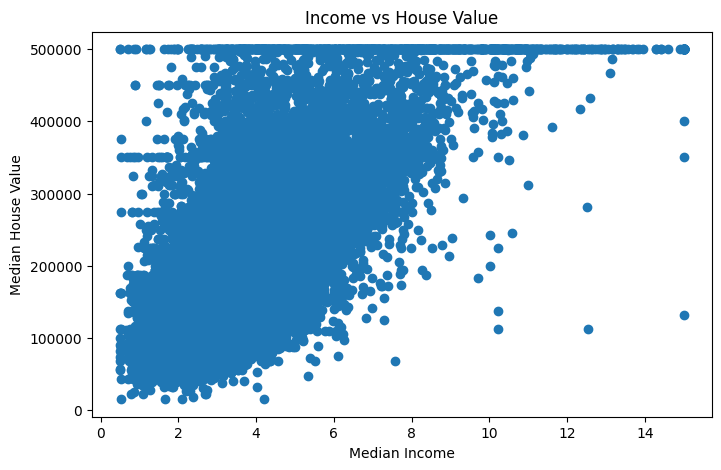

In [24]:
plt.figure(figsize=(8,5))

plt.scatter(
    hp["median_income"],
    hp["median_house_value"]
)

plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.title("Income vs House Value")

plt.show()

In [25]:
numeric_hp = hp.select_dtypes(include='number')

numeric_hp.corr()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924664,-0.108197,0.044568,0.069260,0.099773,0.055310,-0.015176,-0.045967
latitude,-0.924664,1.000000,0.011173,-0.036100,-0.066658,-0.108785,-0.071035,-0.079809,-0.144160
housing_median_age,-0.108197,0.011173,1.000000,-0.361262,-0.318998,-0.296244,-0.302916,-0.119034,0.105623
total_rooms,0.044568,-0.036100,-0.361262,1.000000,0.927253,0.857126,0.918484,0.198050,0.134153
total_bedrooms,0.069260,-0.066658,-0.318998,0.927253,1.000000,0.873910,0.974725,-0.007682,0.049454
population,0.099773,-0.108785,-0.296244,0.857126,0.873910,1.000000,0.907222,0.004834,-0.024650
households,0.055310,-0.071035,-0.302916,0.918484,0.974725,0.907222,1.000000,0.013033,0.065843
median_income,-0.015176,-0.079809,-0.119034,0.198050,-0.007682,0.004834,0.013033,1.000000,0.688075
median_house_value,-0.045967,-0.144160,0.105623,0.134153,0.049454,-0.024650,0.065843,0.688075,1.000000


## Correlation Analysis

Correlation analysis helps identify the strength of relationships between numerical variables.

Features with higher correlation to the target variable may contribute significantly to model performance.

In [26]:
hp["ocean_proximity"].unique()

array(['NEAR BAY', '<1H OCEAN', 'INLAND', 'NEAR OCEAN', 'ISLAND'],
      dtype=object)

In [27]:
hp = pd.get_dummies(
    hp,
    columns=["ocean_proximity"],
    drop_first=True
)

In [28]:
hp.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,False,False,True,False
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,False,False,True,False
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,False,False,True,False
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,False,False,True,False
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,False,False,True,False


## Encoding Categorical Variables

The `ocean_proximity` feature contains categorical values that cannot be directly used by machine learning algorithms.

One-Hot Encoding was applied to convert categorical values into numerical features.

This transformation allows the Linear Regression model to process location-related information effectively.

In [30]:
X = hp.drop("median_house_value", axis=1)

y = hp["median_house_value"]

## Feature Selection

The dataset was divided into:

### Features (X)

All independent variables used for prediction.

### Target (y)

- median_house_value

The target variable represents the median house price that the model will learn to predict.

In [31]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [36]:
X_train.shape
X_test.shape


(4128, 12)

## Train-Test Split

The dataset was divided into training and testing sets.

- Training Data: 80%
- Testing Data: 20%

The training set is used to learn patterns from the data, while the testing set is used to evaluate model performance on unseen observations.

In [38]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## Linear Regression Model

A Linear Regression model was trained using the training dataset.

The model learns relationships between housing characteristics and house prices, allowing it to estimate property values for unseen data.

In [39]:
y_pred = lr.predict(X_test)

In [40]:
y_pred[:10]

array([ 64629.45079786, 134799.34083607, 266063.38139055, 278576.43346807,
       273343.43671457, 150180.30585448, 301239.42581305, 238838.87827418,
       267080.78750892, 418497.86033375])

In [41]:
comparison = pd.DataFrame({
    "Actual": y_test[:10],
    "Predicted": y_pred[:10]
})

comparison

,Actual,Predicted
20046,47700.0,64629.450798
3024,45800.0,134799.340836
15663,500001.0,266063.381391
20484,218600.0,278576.433468
9814,278000.0,273343.436715
13311,158700.0,150180.305854
7113,198200.0,301239.425813
7668,157500.0,238838.878274
18246,340000.0,267080.787509
5723,446600.0,418497.860334


In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, y_pred)
rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("RMSE:", rmse)
print("R2  :", r2)

MAE : 50701.77903133012
RMSE: 70031.41991955669
R2  : 0.6257351821159699


## Model Evaluation

The Linear Regression model was evaluated using standard regression metrics.

### Results

| Metric | Value |
|----------|----------|
| MAE | 50,701 |
| RMSE | 70,031 |
| R² Score | 0.626 |

### Interpretation

- The model's average prediction error is approximately $50,701.
- The RMSE value indicates the presence of some larger prediction errors.
- The R² score of 0.626 suggests that the model explains approximately 62.6% of the variance in house prices.

Overall, the Linear Regression model provides a reasonable baseline for house price prediction and demonstrates the relationship between housing characteristics and property values.

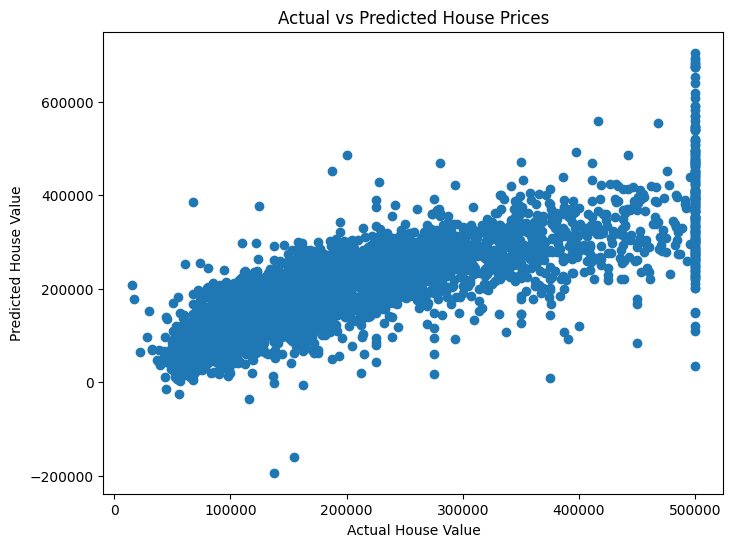

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Prices")

plt.show()